In [3]:
import pandas as pd

df = pd.read_csv("/content/olist_order_reviews_dataset_translated.csv")

print("Dataset shape:", df.shape)
print("Column names:")
print(df.columns.tolist())

df.head()

Dataset shape: (63271, 7)
Column names:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4.0,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5.0,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5.0,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5.0,NaN,I received it well before the stipulated time.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5.0,NaN,Congratulations Lannister stores I loved shopp...,2018-03-01,2018-03-02 10:26:53


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import os

In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       88289
review_comment_message     58275
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
review_id                   0.000
order_id                    0.000
review_score                0.000
review_comment_title       88.289
review_comment_message     58.275
review_creation_date        0.000
review_answer_timestamp     0.000
dtype: float64


In [9]:
print(df["review_score"].value_counts().sort_index())

review_score
1    11858
2     3235
3     8287
4    19200
5    57420
Name: count, dtype: int64


In [14]:
def get_sentiment(score):
    if score >= 4:
        return "Positive"
    elif score <= 2:
        return "Negative"
    else:
        return "Neutral"


df["sentiment"] = df["review_score"].apply(get_sentiment)

df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,sentiment
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59,Positive
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13,Positive
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24,Positive
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,I received it well before the stipulated time.,2017-04-21,2017-04-21 22:02:06,Positive
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Congratulations Lannister stores I loved shopp...,2018-03-01,2018-03-02 10:26:53,Positive


In [15]:
print(df["sentiment"].value_counts())

sentiment
Positive    76620
Negative    15093
Neutral      8287
Name: count, dtype: int64


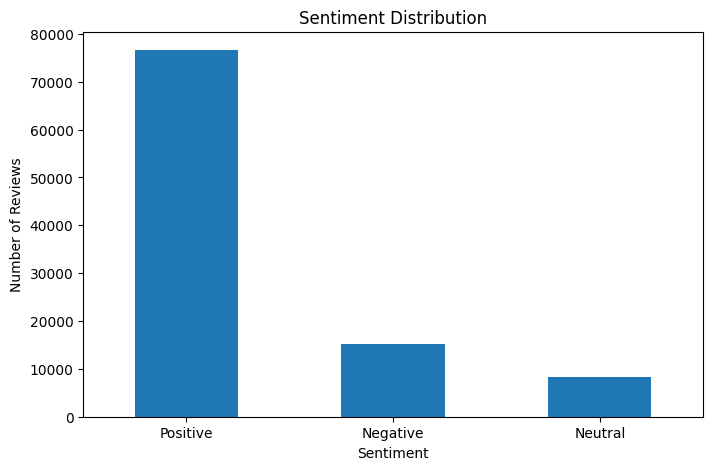

In [16]:
plt.figure(figsize=(8,5))

df["sentiment"].value_counts().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80000
Testing samples: 20000


In [24]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (80000, 5000)
Testing TF-IDF shape: (20000, 5000)


In [25]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [26]:
y_pred = model.predict(X_test_tfidf)

print("Prediction completed!")
print(y_pred[:20])

Prediction completed!
['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Positive'
 'Positive' 'Positive']


In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Model Accuracy: 0.8464
Accuracy Percentage: 84.64 %


In [29]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Negative", "Neutral", "Positive"]
)

print(cm)

[[ 1882    41  1096]
 [  322    45  1290]
 [  292    31 15001]]


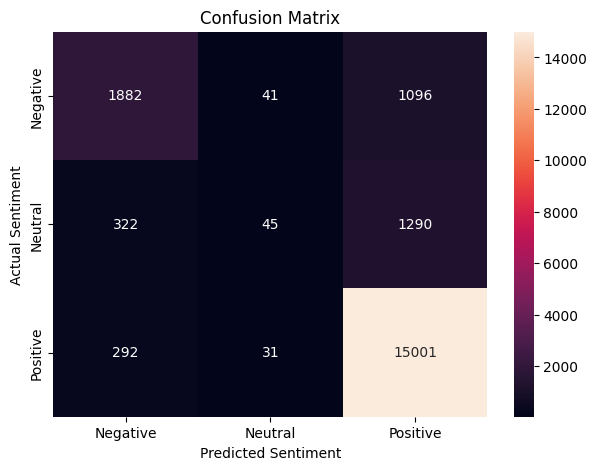

In [30]:
plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

In [31]:
new_reviews = [
    "This product is excellent and I am very happy",
    "Very bad product, I am disappointed",
    "The product is okay"
]

new_reviews_tfidf = tfidf.transform(new_reviews)

predictions = model.predict(new_reviews_tfidf)

for review, sentiment in zip(new_reviews, predictions):
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("-" * 50)

Review: This product is excellent and I am very happy
Predicted Sentiment: Positive
--------------------------------------------------
Review: Very bad product, I am disappointed
Predicted Sentiment: Negative
--------------------------------------------------
Review: The product is okay
Predicted Sentiment: Positive
--------------------------------------------------


In [32]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
